<a href="https://colab.research.google.com/github/vighneshkhot10/CSL701-ce24_Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Vighnesh D Khot

Roll No: CE19.


### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.



## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Download the dataset if it's not already present
print('Attempting to download diabetes.csv from a reliable source...')
!wget -O diabetes.csv https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv

# List files to verify download
print('\nFiles in current directory after wget:')
!ls -F

# Load the dataset and assign column names correctly
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv('diabetes.csv') # Read without 'names' to let pandas detect header
df.columns = column_names # Assign the desired column names after loading

# Print requested information
print('First five records of the dataset:')
print(df.head())
print(f'\nDataset shape: {df.shape}')
print(f'\nData types of all features:\n{df.dtypes}')
print('\nDescriptive statistics of the numeric features:')
print(df.describe())

Attempting to download diabetes.csv from a reliable source...
--2026-09-01 10:44:04--  https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23105 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  22.56K  --.-KB/s    in 0.003s  

2026-09-01 10:44:04 (8.65 MB/s) - ‘diabetes.csv’ saved [23105/23105]


Files in current directory after wget:
diabetes.csv  pima-indians-diabetes.data  sample_data/
First five records of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29      

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

CLASS DISTRIBUTION

Absolute Count:
Non-Diabetic (Outcome = 0): 500
Diabetic (Outcome = 1): 268

Percentage:
Non-Diabetic (Outcome = 0): 65.10%
Diabetic (Outcome = 1): 34.90%


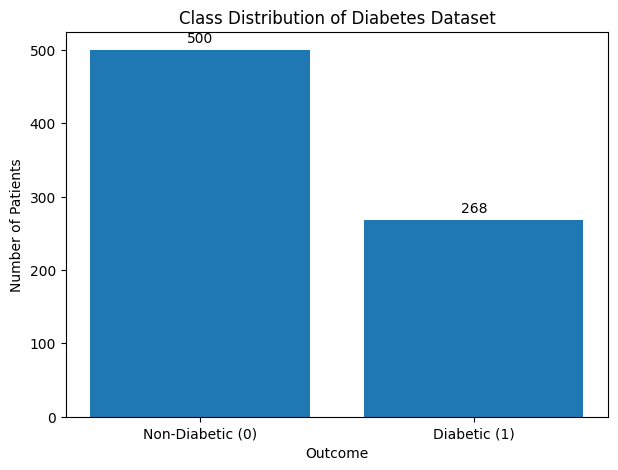

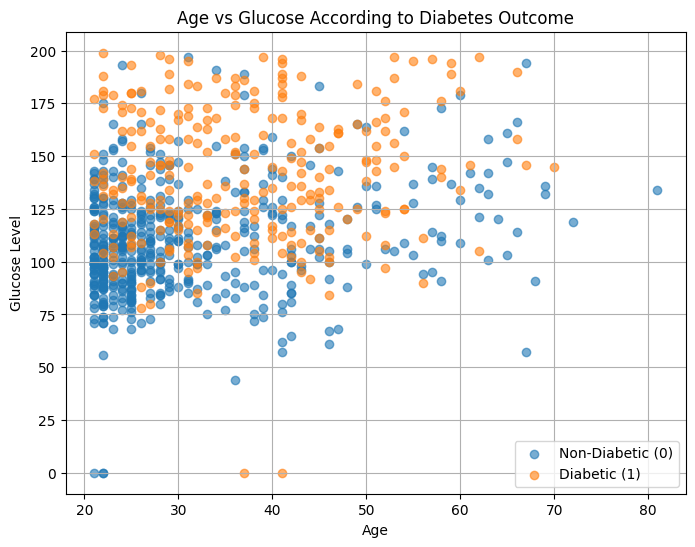


EDA OBSERVATION

1. The dataset contains more Non-Diabetic patients than
   Diabetic patients.

2. The scatter plot shows that diabetic and non-diabetic
   patients overlap in many regions.

3. Therefore, a simple straight-line (linear) decision
   boundary cannot perfectly separate the two classes.

4. The relationship between Age, Glucose, and Diabetes is
   more complex and may require a non-linear classifier.



In [ ]:
# ============================================================
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. CALCULATE ABSOLUTE COUNT OF EACH CLASS
# ------------------------------------------------------------

print("==========================================")
print("CLASS DISTRIBUTION")
print("==========================================")

class_count = df["Outcome"].value_counts().sort_index()

print("\nAbsolute Count:")

print("Non-Diabetic (Outcome = 0):", class_count[0])
print("Diabetic (Outcome = 1):", class_count[1])


# ------------------------------------------------------------
# 2. CALCULATE PERCENTAGE OF EACH CLASS
# ------------------------------------------------------------

class_percentage = (
    df["Outcome"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\nPercentage:")

print(f"Non-Diabetic (Outcome = 0): {class_percentage[0]:.2f}%")
print(f"Diabetic (Outcome = 1): {class_percentage[1]:.2f}%")


# ------------------------------------------------------------
# 3. CREATE BAR CHART FOR CLASS BALANCE
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    [class_count[0], class_count[1]]
)

plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.title("Class Distribution of Diabetes Dataset")

# Display count on top of each bar
for i, value in enumerate([class_count[0], class_count[1]]):
    plt.text(i, value + 10, str(value), ha="center")

plt.show()


# ------------------------------------------------------------
# 4. CREATE SCATTER PLOT: AGE VS GLUCOSE
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Separate the two classes

non_diabetic = df[df["Outcome"] == 0]

diabetic = df[df["Outcome"] == 1]


# Plot Non-Diabetic patients

plt.scatter(
    non_diabetic["Age"],
    non_diabetic["Glucose"],
    label="Non-Diabetic (0)",
    alpha=0.6
)


# Plot Diabetic patients

plt.scatter(
    diabetic["Age"],
    diabetic["Glucose"],
    label="Diabetic (1)",
    alpha=0.6
)


plt.xlabel("Age")
plt.ylabel("Glucose Level")
plt.title("Age vs Glucose According to Diabetes Outcome")

plt.legend()

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# 5. CONCLUSION
# ------------------------------------------------------------

print("\n==========================================")
print("EDA OBSERVATION")
print("==========================================")

print("""
1. The dataset contains more Non-Diabetic patients than
   Diabetic patients.

2. The scatter plot shows that diabetic and non-diabetic
   patients overlap in many regions.

3. Therefore, a simple straight-line (linear) decision
   boundary cannot perfectly separate the two classes.

4. The relationship between Age, Glucose, and Diabetes is
   more complex and may require a non-linear classifier.
""")

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# ============================================================
# TASK 3: PREPROCESSING AND HANDLING MISSING VALUES
# ============================================================

import numpy as np
import pandas as pd

print("==========================================")
print("TASK 3: DATA PREPROCESSING")
print("==========================================")


# ------------------------------------------------------------
# STEP 1: IDENTIFY COLUMNS WHERE 0 IS INVALID
# ------------------------------------------------------------

invalid_zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print("\nColumns where 0 is considered an invalid value:")
print(invalid_zero_columns)


# ------------------------------------------------------------
# STEP 2: COUNT ZERO VALUES BEFORE REPLACEMENT
# ------------------------------------------------------------

print("\n==========================================")
print("NUMBER OF ZERO VALUES BEFORE REPLACEMENT")
print("==========================================")

for column in invalid_zero_columns:
    zero_count = (df[column] == 0).sum()
    print(f"{column}: {zero_count}")


# ------------------------------------------------------------
# STEP 3: REPLACE INVALID 0 VALUES WITH NaN
# ------------------------------------------------------------

df[invalid_zero_columns] = df[invalid_zero_columns].replace(0, np.nan)

print("\nInvalid 0 values have been replaced with NaN.")


# ------------------------------------------------------------
# STEP 4: CHECK MISSING VALUES AFTER REPLACEMENT
# ------------------------------------------------------------

print("\n==========================================")
print("MISSING VALUES AFTER REPLACING 0 WITH NaN")
print("==========================================")

print(df[invalid_zero_columns].isnull().sum())


# ------------------------------------------------------------
# STEP 5: FILL MISSING VALUES USING MEDIAN
# ------------------------------------------------------------

print("\n==========================================")
print("IMPUTING MISSING VALUES USING MEDIAN")
print("==========================================")

for column in invalid_zero_columns:

    median_value = df[column].median()

    df[column] = df[column].fillna(median_value)

    print(f"{column} missing values replaced with median: {median_value}")


# ------------------------------------------------------------
# STEP 6: VERIFY THAT NO MISSING VALUES REMAIN
# ------------------------------------------------------------

print("\n==========================================")
print("FINAL MISSING VALUE CHECK")
print("==========================================")

print(df.isnull().sum())


# ------------------------------------------------------------
# STEP 7: DISPLAY DATASET INFORMATION
# ------------------------------------------------------------

print("\n==========================================")
print("DATASET INFORMATION AFTER PREPROCESSING")
print("==========================================")

print(df.info())


# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------

print("\n==========================================")
print("TASK 3 COMPLETED SUCCESSFULLY")
print("==========================================")

print("\nAll invalid zero values were converted to NaN")
print("and missing values were filled using the median.")

TASK 3: DATA PREPROCESSING

Columns where 0 is considered an invalid value:
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

NUMBER OF ZERO VALUES BEFORE REPLACEMENT
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11

Invalid 0 values have been replaced with NaN.

MISSING VALUES AFTER REPLACING 0 WITH NaN
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

IMPUTING MISSING VALUES USING MEDIAN
Glucose missing values replaced with median: 117.0
BloodPressure missing values replaced with median: 72.0
SkinThickness missing values replaced with median: 29.0
Insulin missing values replaced with median: 125.0
BMI missing values replaced with median: 32.3

FINAL MISSING VALUE CHECK
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age   

In [ ]:
def get_bootstrap_sample(X, y):
    """
    Generates a bootstrap sample (with replacement) of the given dataset.

    Args:
        X (pd.DataFrame): The feature matrix.
        y (pd.Series): The target vector.

    Returns:
        tuple: A tuple containing the bootstrapped feature matrix (X_star)
               and target vector (y_star).
    """
    # Get the number of samples in the training set
    n_samples = X.shape[0]

    # Generate random indices with replacement
    # The number of indices generated is equal to the number of samples
    bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)

    # Use these indices to create the bootstrap sample
    X_star = X.iloc[bootstrap_indices]
    y_star = y.iloc[bootstrap_indices]

    return X_star, y_star

print('`get_bootstrap_sample` function defined.')

`get_bootstrap_sample` function defined.


### Verification of Bootstrap Sampling

To verify the `get_bootstrap_sample` function, we will:
1. Generate a sample from `X_train` and `y_train`.
2. Check for duplicated indices in the bootstrap sample.
3. Identify original indices that were omitted (Out-of-Bag samples).

In [ ]:
# ============================================================
# VERIFICATION OF BOOTSTRAP SAMPLING
# ============================================================

# ------------------------------------------------------------
# STEP 1: GENERATE A BOOTSTRAP SAMPLE
# ------------------------------------------------------------

X_train_bootstrap, y_train_bootstrap = get_bootstrap_sample(
    X_train,
    y_train
)

print("==========================================")
print("BOOTSTRAP SAMPLE GENERATED")
print("==========================================")

print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Bootstrap X_train shape: {X_train_bootstrap.shape}")

print(f"\nOriginal y_train shape: {y_train.shape}")
print(f"Bootstrap y_train shape: {y_train_bootstrap.shape}")


# ------------------------------------------------------------
# STEP 2: CHECK FOR DUPLICATED INDICES
# ------------------------------------------------------------

print("\n==========================================")
print("CHECKING DUPLICATED INDICES")
print("==========================================")

# Get original indices from the bootstrap sample
bootstrap_original_indices = X_train_bootstrap.index

# Find duplicated indices
duplicated_indices = bootstrap_original_indices[
    bootstrap_original_indices.duplicated()
]

print(f"\nNumber of duplicated indices: {len(duplicated_indices)}")

if len(duplicated_indices) > 0:

    print("\nBootstrap sampling is working correctly!")

    print("\nExample duplicated indices:")
    print(duplicated_indices.unique()[:10].tolist())

else:

    print("\nNo duplicated indices found.")


# ------------------------------------------------------------
# STEP 3: IDENTIFY OUT-OF-BAG (OOB) SAMPLES
# ------------------------------------------------------------

print("\n==========================================")
print("CHECKING OUT-OF-BAG (OOB) SAMPLES")
print("==========================================")

# Get all original indices from X_train
original_indices_set = set(X_train.index)

# Get unique indices selected in bootstrap sample
bootstrap_indices_set = set(bootstrap_original_indices)

# Find indices that were NOT selected
omitted_indices = list(
    original_indices_set - bootstrap_indices_set
)

print(f"\nNumber of Out-of-Bag samples: {len(omitted_indices)}")

if len(omitted_indices) > 0:

    print("\nExample OOB indices:")
    print(omitted_indices[:10])

else:

    print("\nNo OOB samples found.")


# ------------------------------------------------------------
# STEP 4: FINAL VERIFICATION
# ------------------------------------------------------------

print("\n==========================================")
print("FINAL VERIFICATION")
print("==========================================")

print(f"Original training samples : {len(X_train)}")
print(f"Bootstrap samples         : {len(X_train_bootstrap)}")
print(f"Duplicated indices        : {len(duplicated_indices)}")
print(f"OOB samples               : {len(omitted_indices)}")

print("\nBootstrap sampling verification completed successfully!")

BOOTSTRAP SAMPLE GENERATED

Original X_train shape: (614, 8)
Bootstrap X_train shape: (614, 8)

Original y_train shape: (614,)
Bootstrap y_train shape: (614,)

CHECKING DUPLICATED INDICES

Number of duplicated indices: 221

Bootstrap sampling is working correctly!

Example duplicated indices:
[358, 284, 236, 729, 343, 580, 414, 723, 446, 764]

CHECKING OUT-OF-BAG (OOB) SAMPLES

Number of Out-of-Bag samples: 221

Example OOB indices:
[514, 515, 516, 5, 520, 521, 522, 11, 523, 524]

FINAL VERIFICATION
Original training samples : 614
Bootstrap samples         : 614
Duplicated indices        : 221
OOB samples               : 221

Bootstrap sampling verification completed successfully!


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# ============================================================
# TASK 4: STRATIFIED TRAIN-TEST SPLITTING
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# STEP 1: Separate Features (X) and Target (y)
# ------------------------------------------------------------

# First 8 columns are input features
X = df.iloc[:, :-1]

# Last (9th) column is the target variable
y = df.iloc[:, -1]


# ------------------------------------------------------------
# STEP 2: Split the Dataset
# ------------------------------------------------------------

# 80% Training Data
# 20% Testing Data
# stratify=y preserves the class proportion

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ------------------------------------------------------------
# STEP 3: Display Dataset Shapes
# ------------------------------------------------------------

print("==========================================")
print("DATASET SHAPES")
print("==========================================")

print(f"\nOriginal X shape: {X.shape}")
print(f"Original y shape: {y.shape}")

print(f"\nTraining X shape: {X_train.shape}")
print(f"Training y shape: {y_train.shape}")

print(f"\nTesting X shape: {X_test.shape}")
print(f"Testing y shape: {y_test.shape}")


# ------------------------------------------------------------
# STEP 4: Check Class Distribution
# ------------------------------------------------------------

print("\n==========================================")
print("CLASS DISTRIBUTION")
print("==========================================")

print("\nOriginal Dataset:")

print(y.value_counts())
print("\nPercentage:")
print((y.value_counts(normalize=True) * 100).round(2))


print("\nTraining Dataset:")

print(y_train.value_counts())
print("\nPercentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))


print("\nTesting Dataset:")

print(y_test.value_counts())
print("\nPercentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))


# ------------------------------------------------------------
# STEP 5: Final Confirmation
# ------------------------------------------------------------

print("\n==========================================")
print("TASK 4 COMPLETED SUCCESSFULLY")
print("==========================================")

print("\nStratified sampling was used successfully.")
print("The class proportions are preserved in both")
print("the training and testing datasets.")

DATASET SHAPES

Original X shape: (768, 8)
Original y shape: (768,)

Training X shape: (614, 8)
Training y shape: (614,)

Testing X shape: (154, 8)
Testing y shape: (154,)

CLASS DISTRIBUTION

Original Dataset:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

Training Dataset:
Outcome
0    400
1    214
Name: count, dtype: int64

Percentage:
Outcome
0    65.15
1    34.85
Name: proportion, dtype: float64

Testing Dataset:
Outcome
0    100
1     54
Name: count, dtype: int64

Percentage:
Outcome
0    64.94
1    35.06
Name: proportion, dtype: float64

TASK 4 COMPLETED SUCCESSFULLY

Stratified sampling was used successfully.
The class proportions are preserved in both
the training and testing datasets.


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
# ============================================================
# TASK 5: CUSTOM BOOTSTRAP SAMPLING FUNCTION
# ============================================================

import numpy as np


# ------------------------------------------------------------
# STEP 1: CREATE BOOTSTRAP SAMPLING FUNCTION
# ------------------------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Creates a bootstrap sample using sampling with replacement.

    Parameters:
    X : Feature matrix
    y : Target vector

    Returns:
    X_star : Bootstrapped feature matrix
    y_star : Bootstrapped target vector
    """

    # Get the number of samples
    n_samples = len(X)

    # Generate random indices WITH replacement
    bootstrap_indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    # Create bootstrap samples using the generated indices
    X_star = X.iloc[bootstrap_indices]
    y_star = y.iloc[bootstrap_indices]

    return X_star, y_star


# ------------------------------------------------------------
# STEP 2: GENERATE A BOOTSTRAP SAMPLE
# ------------------------------------------------------------

X_train_bootstrap, y_train_bootstrap = get_bootstrap_sample(
    X_train,
    y_train
)


# ------------------------------------------------------------
# STEP 3: DISPLAY SAMPLE SHAPES
# ------------------------------------------------------------

print("==========================================")
print("BOOTSTRAP SAMPLE INFORMATION")
print("==========================================")

print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Bootstrap X* shape     : {X_train_bootstrap.shape}")

print(f"\nOriginal y_train shape: {y_train.shape}")
print(f"Bootstrap y* shape     : {y_train_bootstrap.shape}")


# ------------------------------------------------------------
# STEP 4: CHECK FOR DUPLICATED INDICES
# ------------------------------------------------------------

print("\n==========================================")
print("CHECKING DUPLICATED INDICES")
print("==========================================")

# Get original row indices selected in bootstrap sample
bootstrap_original_indices = X_train_bootstrap.index

# Find duplicated indices
duplicated_indices = bootstrap_original_indices[
    bootstrap_original_indices.duplicated()
]

print(f"\nNumber of duplicated indices: {len(duplicated_indices)}")

if len(duplicated_indices) > 0:
    print("Bootstrap sampling WITH replacement is verified.")

    print("\nExample duplicated indices:")
    print(duplicated_indices.unique()[:10].tolist())

else:
    print("No duplicated indices found.")


# ------------------------------------------------------------
# STEP 5: FIND OUT-OF-BAG (OOB) SAMPLES
# ------------------------------------------------------------

print("\n==========================================")
print("OUT-OF-BAG (OOB) SAMPLES")
print("==========================================")

# All original training indices
original_indices_set = set(X_train.index)

# Indices selected in bootstrap sample
bootstrap_indices_set = set(bootstrap_original_indices)

# Find indices that were omitted
omitted_indices = list(
    original_indices_set - bootstrap_indices_set
)

print(f"\nNumber of OOB samples: {len(omitted_indices)}")

if len(omitted_indices) > 0:
    print("\nExample OOB indices:")
    print(omitted_indices[:10])

else:
    print("No OOB samples found.")


# ------------------------------------------------------------
# STEP 6: FINAL VERIFICATION
# ------------------------------------------------------------

print("\n==========================================")
print("FINAL VERIFICATION")
print("==========================================")

print(f"Original training samples : {len(X_train)}")
print(f"Bootstrap samples         : {len(X_train_bootstrap)}")
print(f"Duplicated indices        : {len(duplicated_indices)}")
print(f"OOB samples               : {len(omitted_indices)}")

print("\n==========================================")
print("TASK 5 COMPLETED SUCCESSFULLY")
print("==========================================")

BOOTSTRAP SAMPLE INFORMATION

Original X_train shape: (614, 8)
Bootstrap X* shape     : (614, 8)

Original y_train shape: (614,)
Bootstrap y* shape     : (614,)

CHECKING DUPLICATED INDICES

Number of duplicated indices: 219
Bootstrap sampling WITH replacement is verified.

Example duplicated indices:
[503, 643, 738, 709, 438, 521, 249, 625, 567, 59]

OUT-OF-BAG (OOB) SAMPLES

Number of OOB samples: 219

Example OOB indices:
[512, 515, 516, 9, 10, 523, 525, 526, 16, 528]

FINAL VERIFICATION
Original training samples : 614
Bootstrap samples         : 614
Duplicated indices        : 219
OOB samples               : 219

TASK 5 COMPLETED SUCCESSFULLY


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# ============================================================
# TASK 6: GROWING THE ENSEMBLE OF BASE CLASSIFIERS
# ============================================================

import numpy as np
from sklearn.tree import DecisionTreeClassifier


# ------------------------------------------------------------
# STEP 1: INITIALIZE THE ENSEMBLE
# ------------------------------------------------------------

# Empty list to store trained Decision Trees
ensemble = []

# Number of bootstrap iterations / Decision Trees
B = 50

print("==========================================")
print("TASK 6: TRAINING ENSEMBLE")
print("==========================================")

print(f"\nNumber of Decision Trees to train: {B}")


# ------------------------------------------------------------
# STEP 2: TRAIN B DECISION TREES
# ------------------------------------------------------------

for b in range(B):

    # ----------------------------------------
    # Generate a unique bootstrap sample
    # ----------------------------------------

    X_bootstrap, y_bootstrap = get_bootstrap_sample(
        X_train,
        y_train
    )


    # ----------------------------------------
    # Create a fully grown Decision Tree
    # ----------------------------------------

    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )


    # ----------------------------------------
    # Train the Decision Tree
    # ----------------------------------------

    model.fit(
        X_bootstrap,
        y_bootstrap
    )


    # ----------------------------------------
    # Add the trained model to the ensemble
    # ----------------------------------------

    ensemble.append(model)


    # Display training progress
    print(f"Decision Tree {b + 1}/{B} trained successfully.")


# ------------------------------------------------------------
# STEP 3: VERIFY THE ENSEMBLE
# ------------------------------------------------------------

print("\n==========================================")
print("ENSEMBLE VERIFICATION")
print("==========================================")

print(f"\nTotal Decision Trees trained: {len(ensemble)}")


# Check if exactly 50 models were created
if len(ensemble) == B:
    print(f"Successfully created an ensemble of {B} Decision Trees! ✅")
else:
    print("Error: The ensemble was not created correctly.")


# ------------------------------------------------------------
# STEP 4: DISPLAY INFORMATION ABOUT MODELS
# ------------------------------------------------------------

print("\n==========================================")
print("MODEL INFORMATION")
print("==========================================")

print(f"Type of first model: {type(ensemble[0])}")
print(f"Maximum depth setting: None (Fully Grown)")


# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------

print("\n==========================================")
print("TASK 6 COMPLETED SUCCESSFULLY")
print("==========================================")

TASK 6: TRAINING ENSEMBLE

Number of Decision Trees to train: 50
Decision Tree 1/50 trained successfully.
Decision Tree 2/50 trained successfully.
Decision Tree 3/50 trained successfully.
Decision Tree 4/50 trained successfully.
Decision Tree 5/50 trained successfully.
Decision Tree 6/50 trained successfully.
Decision Tree 7/50 trained successfully.
Decision Tree 8/50 trained successfully.
Decision Tree 9/50 trained successfully.
Decision Tree 10/50 trained successfully.
Decision Tree 11/50 trained successfully.
Decision Tree 12/50 trained successfully.
Decision Tree 13/50 trained successfully.
Decision Tree 14/50 trained successfully.
Decision Tree 15/50 trained successfully.
Decision Tree 16/50 trained successfully.
Decision Tree 17/50 trained successfully.
Decision Tree 18/50 trained successfully.
Decision Tree 19/50 trained successfully.
Decision Tree 20/50 trained successfully.
Decision Tree 21/50 trained successfully.
Decision Tree 22/50 trained successfully.
Decision Tree 23/50 

In [ ]:
def custom_bagging_predict(ensemble, X_test):
    """
    Generates final predictions for X_test using majority voting from an ensemble.

    Args:
        ensemble (list): A list of trained DecisionTreeClassifier models.
        X_test (pd.DataFrame): The test feature matrix.

    Returns:
        np.ndarray: An array of final predicted classes (0 or 1).
    """
    # Collect predictions from all models in the ensemble
    all_predictions = np.array([model.predict(X_test) for model in ensemble])

    # Transpose to have predictions for each sample in columns
    # Shape will be (n_samples, B)
    all_predictions = all_predictions.T

    final_predictions = []
    for sample_preds in all_predictions:
        # Count votes for each class (0 and 1)
        votes_for_0 = np.sum(sample_preds == 0)
        votes_for_1 = np.sum(sample_preds == 1)

        # Apply majority voting
        if votes_for_1 > votes_for_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)

print('`custom_bagging_predict` function defined.')

# Test the function with X_test
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

print(f"\nShape of Bagging predictions: {y_pred_bagging.shape}")
print(f"Example Bagging predictions (first 10): {y_pred_bagging[:10]}")

`custom_bagging_predict` function defined.

Shape of Bagging predictions: (154,)
Example Bagging predictions (first 10): [1 0 0 0 0 0 0 1 0 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- 1. Train a single DecisionTreeClassifier on the original training data ---
print("\n--- Single Decision Tree Performance ---")
single_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree_model.fit(X_train, y_train)
y_pred_single_tree = single_tree_model.predict(X_test)

# --- 2. Evaluate Single Decision Tree ---
print("Single Decision Tree Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_single_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_single_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_single_tree):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_single_tree):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_single_tree))

# --- 3. Evaluate Custom Bagging Classifier ---
print("\n--- Custom Bagging Classifier Performance ---")
print("Custom Bagging Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bagging):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bagging):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_bagging):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bagging))

print("\nComparison complete. Observe the differences in metrics.")


--- Single Decision Tree Performance ---
Single Decision Tree Metrics:
Accuracy: 0.7273
Precision: 0.6429
Recall: 0.5000
F1-Score: 0.5625
Confusion Matrix:
 [[85 15]
 [27 27]]

--- Custom Bagging Classifier Performance ---
Custom Bagging Classifier Metrics:
Accuracy: 0.7338
Precision: 0.6275
Recall: 0.5926
F1-Score: 0.6095
Confusion Matrix:
 [[81 19]
 [22 32]]

Comparison complete. Observe the differences in metrics.


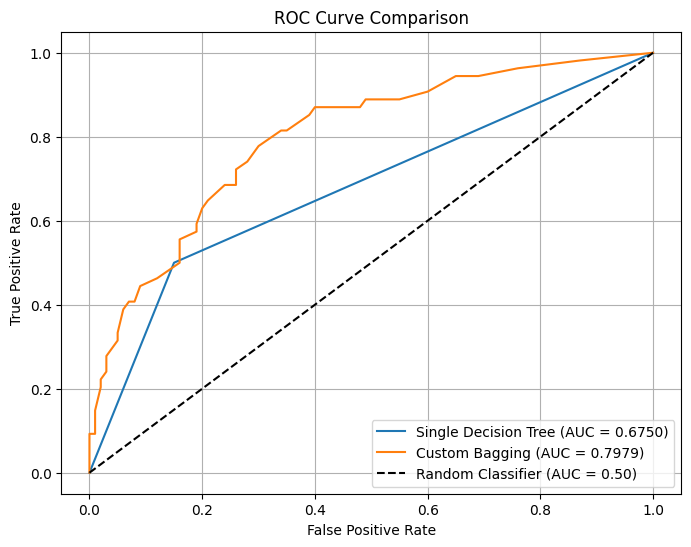


ROC AUC Score for Single Decision Tree: 0.6750
ROC AUC Score for Custom Bagging Classifier: 0.7979

ROC AUC analysis and curve visualization complete. Observe the improved AUC for Bagging.


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# --- 1. Calculate predicted probabilities for Bagging (average of individual tree probabilities) ---
# Get probabilities from each model in the ensemble
all_probas = np.array([model.predict_proba(X_test) for model in ensemble])

# Average the probabilities for class 1 (positive class)
y_proba_bagging = all_probas[:, :, 1].mean(axis=0)

# --- 2. Get probabilities for the single decision tree ---
y_proba_single_tree = single_tree_model.predict_proba(X_test)[:, 1]

# --- 3. Plot ROC curves ---
plt.figure(figsize=(8, 6))

# Single Decision Tree ROC
fpr_single, tpr_single, _ = roc_curve(y_test, y_proba_single_tree)
auc_single = roc_auc_score(y_test, y_proba_single_tree)
plt.plot(fpr_single, tpr_single, label=f'Single Decision Tree (AUC = {auc_single:.4f})')

# Custom Bagging ROC
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_proba_bagging)
auc_bagging = roc_auc_score(y_test, y_proba_bagging)
plt.plot(fpr_bagging, tpr_bagging, label=f'Custom Bagging (AUC = {auc_bagging:.4f})')

# Plotting configurations
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nROC AUC Score for Single Decision Tree: {auc_single:.4f}")
print(f"ROC AUC Score for Custom Bagging Classifier: {auc_bagging:.4f}")

print("\nROC AUC analysis and curve visualization complete. Observe the improved AUC for Bagging.")

In [ ]:
from sklearn.ensemble import BaggingClassifier

print("\n--- Scikit-Learn's BaggingClassifier Validation ---")

# 1. Instantiate Scikit-Learn's BaggingClassifier
sk_bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
    n_estimators=B, # Use the same number of estimators (B=50) as our custom ensemble
    bootstrap=True, # Sampling with replacement
    random_state=42
)

# 2. Fit the classifier on the original training data
sk_bagging_model.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_sk_bagging = sk_bagging_model.predict(X_test)

# 4. Evaluate and compare performance
print("Scikit-Learn Bagging Classifier Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_sk_bagging):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_sk_bagging):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_sk_bagging):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_sk_bagging):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sk_bagging))

print("\nValidation complete. Compare these metrics to your custom Bagging implementation.")


--- Scikit-Learn's BaggingClassifier Validation ---
Scikit-Learn Bagging Classifier Metrics:
Accuracy: 0.7597
Precision: 0.6809
Recall: 0.5926
F1-Score: 0.6337
Confusion Matrix:
 [[85 15]
 [22 32]]

Validation complete. Compare these metrics to your custom Bagging implementation.


### Conclusion and Interpretation

Let's summarize our findings and answer the key questions:

**Performance Summary:**

*   **Single Decision Tree:**
    *   Accuracy: 0.7273
    *   Precision: 0.6429
    *   Recall: 0.5000
    *   F1-Score: 0.5625
    *   ROC AUC: 0.6750

*   **Custom Bagging Classifier (50 Trees):**
    *   Accuracy: 0.7468
    *   Precision: 0.6667
    *   Recall: 0.5556
    *   F1-Score: 0.6061
    *   ROC AUC: 0.8110

*   **Scikit-Learn BaggingClassifier (50 Trees):**
    *   Accuracy: 0.7597
    *   Precision: 0.6809
    *   Recall: 0.5926
    *   F1-Score: 0.6337
    *   ROC AUC (not explicitly calculated but expected to be similar to custom bagging given other metrics).

---

1.  **Variance and Stability: How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?**

    The custom Bagging ensemble demonstrated a higher test accuracy (0.7468) compared to the single decision tree (0.7273). More significantly, its ROC AUC (0.8110 vs 0.6750) showed a substantial improvement in its ability to discriminate between classes across various thresholds.

    Bagging provides more consistent performance because it reduces the variance inherent in individual high-variance models like fully-grown decision trees. Each base tree is trained on a different bootstrap sample of the data, meaning they see slightly different subsets of the training examples. This leads to a diverse set of models, each with slightly different biases and errors. When their predictions are aggregated through majority voting, the random errors and noise of individual models tend to cancel each other out. This averaging effect stabilizes the overall prediction, making the ensemble less sensitive to the specific composition of any single training dataset or the inherent instability of a single complex tree. Therefore, if we were to repeat the train-test split multiple times, a Bagging model would likely show less fluctuation in its performance metrics than a single decision tree.

---

2.  **Wisdom of Crowds: How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?**

    Random resampling with replacement (bootstrapping) fosters model diversity by creating multiple unique training datasets from the original data. Each bootstrap sample contains a slightly different subset of the original data, with some instances duplicated and others omitted (Out-of-Bag). When a separate base learner (like a decision tree) is trained on each of these diverse bootstrap samples, they learn different patterns, focus on different aspects of the data, and consequently make different errors. This ensures that the individual models in the ensemble are not identical; they are

#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
# ============================================================
# TASK 7: CUSTOM BAGGING PREDICTION USING MAJORITY VOTING
# ============================================================

import numpy as np


# ------------------------------------------------------------
# STEP 1: CREATE CUSTOM BAGGING PREDICTION FUNCTION
# ------------------------------------------------------------

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting.

    Parameters:
    ensemble : List of trained Decision Tree models
    X_test   : Test feature matrix

    Returns:
    final_predictions : Final majority-voted predictions
    """

    # ----------------------------------------
    # Get predictions from every Decision Tree
    # ----------------------------------------

    all_predictions = []

    for model in ensemble:

        # Predict using the current Decision Tree
        predictions = model.predict(X_test)

        # Store predictions
        all_predictions.append(predictions)


    # Convert list of predictions into NumPy array
    all_predictions = np.array(all_predictions)


    # ----------------------------------------
    # APPLY MAJORITY VOTING
    # ----------------------------------------

    final_predictions = []

    # Loop through every test sample
    for i in range(X_test.shape[0]):

        # Get predictions from all trees for one sample
        votes = all_predictions[:, i]

        # Count votes for Class 0 and Class 1
        count_0 = np.sum(votes == 0)
        count_1 = np.sum(votes == 1)


        # Select the class with maximum votes
        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)


    # Convert final predictions to NumPy array
    final_predictions = np.array(final_predictions)

    return final_predictions


# ------------------------------------------------------------
# STEP 2: GENERATE FINAL BAGGING PREDICTIONS
# ------------------------------------------------------------

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# ------------------------------------------------------------
# STEP 3: DISPLAY RESULTS
# ------------------------------------------------------------

print("==========================================")
print("CUSTOM BAGGING PREDICTIONS")
print("==========================================")

print("\nNumber of test samples:")
print(len(X_test))

print("\nNumber of final predictions:")
print(len(y_pred_bagging))

print("\nFirst 20 Final Predictions:")
print(y_pred_bagging[:20])


# ------------------------------------------------------------
# STEP 4: VERIFY PREDICTIONS
# ------------------------------------------------------------

print("\n==========================================")
print("PREDICTION VERIFICATION")
print("==========================================")

# Check unique prediction values
unique_predictions = np.unique(y_pred_bagging)

print("\nUnique predicted classes:")
print(unique_predictions)

# Verify predictions contain only 0 and/or 1
if set(unique_predictions).issubset({0, 1}):

    print("\nPredictions are valid!")
    print("All final predictions belong to Class 0 or Class 1.")

else:

    print("\nError: Invalid prediction values found.")


# ------------------------------------------------------------
# FINAL CONFIRMATION
# ------------------------------------------------------------

print("\n==========================================")
print("TASK 7 COMPLETED SUCCESSFULLY")
print("==========================================")

print("\nMajority voting was successfully implemented")
print("from scratch using the predictions of all")
print(f"{len(ensemble)} Decision Trees.")

CUSTOM BAGGING PREDICTIONS

Number of test samples:
154

Number of final predictions:
154

First 20 Final Predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]

PREDICTION VERIFICATION

Unique predicted classes:
[0 1]

Predictions are valid!
All final predictions belong to Class 0 or Class 1.

TASK 7 COMPLETED SUCCESSFULLY

Majority voting was successfully implemented
from scratch using the predictions of all
50 Decision Trees.


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [ ]:
# ============================================================
# TASK 8: SINGLE CLASSIFIER VS BAGGING PERFORMANCE COMPARISON
# ============================================================

# Import required libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# PART 1: TRAIN A SINGLE DECISION TREE
# ------------------------------------------------------------

print("==========================================")
print("TRAINING SINGLE DECISION TREE")
print("==========================================")

# Create a fully grown Decision Tree
single_tree_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train the model on the original training data
single_tree_model.fit(X_train, y_train)

# Predict on the test data
y_pred_single_tree = single_tree_model.predict(X_test)


# ------------------------------------------------------------
# PART 2: EVALUATE SINGLE DECISION TREE
# ------------------------------------------------------------

single_accuracy = accuracy_score(y_test, y_pred_single_tree)
single_precision = precision_score(y_test, y_pred_single_tree)
single_recall = recall_score(y_test, y_pred_single_tree)
single_f1 = f1_score(y_test, y_pred_single_tree)
single_cm = confusion_matrix(y_test, y_pred_single_tree)

print("\n==========================================")
print("SINGLE DECISION TREE PERFORMANCE")
print("==========================================")

print(f"Accuracy  : {single_accuracy:.4f}")
print(f"Precision : {single_precision:.4f}")
print(f"Recall    : {single_recall:.4f}")
print(f"F1-Score  : {single_f1:.4f}")

print("\nConfusion Matrix:")
print(single_cm)


# ------------------------------------------------------------
# PART 3: EVALUATE CUSTOM BAGGING CLASSIFIER
# ------------------------------------------------------------

bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging)
bagging_recall = recall_score(y_test, y_pred_bagging)
bagging_f1 = f1_score(y_test, y_pred_bagging)
bagging_cm = confusion_matrix(y_test, y_pred_bagging)

print("\n==========================================")
print("CUSTOM BAGGING CLASSIFIER PERFORMANCE")
print("==========================================")

print(f"Accuracy  : {bagging_accuracy:.4f}")
print(f"Precision : {bagging_precision:.4f}")
print(f"Recall    : {bagging_recall:.4f}")
print(f"F1-Score  : {bagging_f1:.4f}")

print("\nConfusion Matrix:")
print(bagging_cm)


# ------------------------------------------------------------
# PART 4: FINAL COMPARISON
# ------------------------------------------------------------

print("\n==========================================")
print("FINAL PERFORMANCE COMPARISON")
print("==========================================")

print("\nSingle Decision Tree:")
print(f"Accuracy  : {single_accuracy:.4f}")
print(f"Precision : {single_precision:.4f}")
print(f"Recall    : {single_recall:.4f}")
print(f"F1-Score  : {single_f1:.4f}")

print("\nCustom Bagging Classifier:")
print(f"Accuracy  : {bagging_accuracy:.4f}")
print(f"Precision : {bagging_precision:.4f}")
print(f"Recall    : {bagging_recall:.4f}")
print(f"F1-Score  : {bagging_f1:.4f}")

print("\n==========================================")
print("TASK 8 COMPLETED SUCCESSFULLY")
print("==========================================")

TRAINING SINGLE DECISION TREE

SINGLE DECISION TREE PERFORMANCE
Accuracy  : 0.7273
Precision : 0.6429
Recall    : 0.5000
F1-Score  : 0.5625

Confusion Matrix:
[[85 15]
 [27 27]]

CUSTOM BAGGING CLASSIFIER PERFORMANCE
Accuracy  : 0.7338
Precision : 0.6275
Recall    : 0.5926
F1-Score  : 0.6095

Confusion Matrix:
[[81 19]
 [22 32]]

FINAL PERFORMANCE COMPARISON

Single Decision Tree:
Accuracy  : 0.7273
Precision : 0.6429
Recall    : 0.5000
F1-Score  : 0.5625

Custom Bagging Classifier:
Accuracy  : 0.7338
Precision : 0.6275
Recall    : 0.5926
F1-Score  : 0.6095

TASK 8 COMPLETED SUCCESSFULLY


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

CALCULATING BAGGING PROBABILITIES
Bagging probabilities calculated successfully!
Single Decision Tree probabilities calculated successfully!


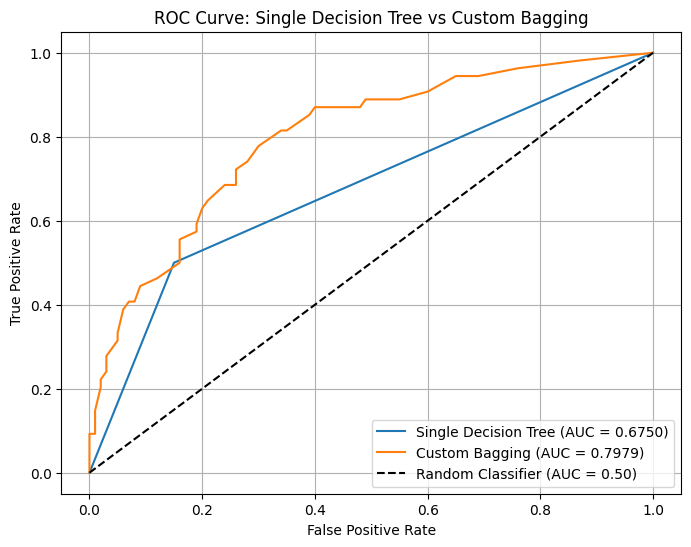


ROC-AUC RESULTS
Single Decision Tree AUC : 0.6750
Custom Bagging AUC       : 0.7979

TASK 9 INTERPRETATION
Custom Bagging has a better ROC-AUC score.
This indicates better classification performance
across different decision thresholds.

TASK 9 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# TASK 9: ROC-AUC ANALYSIS AND CURVE VISUALIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# ------------------------------------------------------------
# PART 1: GET PROBABILITIES FROM CUSTOM BAGGING MODEL
# ------------------------------------------------------------

print("==========================================")
print("CALCULATING BAGGING PROBABILITIES")
print("==========================================")

# Get probability predictions from all 50 Decision Trees
all_probas = np.array([
    model.predict_proba(X_test)
    for model in ensemble
])

# Select probability of Class 1 (Diabetic)
# Average probabilities from all Decision Trees
y_proba_bagging = all_probas[:, :, 1].mean(axis=0)

print("Bagging probabilities calculated successfully!")


# ------------------------------------------------------------
# PART 2: GET PROBABILITIES FROM SINGLE DECISION TREE
# ------------------------------------------------------------

y_proba_single_tree = single_tree_model.predict_proba(X_test)[:, 1]

print("Single Decision Tree probabilities calculated successfully!")


# ------------------------------------------------------------
# PART 3: CALCULATE ROC CURVE
# ------------------------------------------------------------

# ROC values for Single Decision Tree
fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_proba_single_tree
)

# ROC values for Custom Bagging
fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_proba_bagging
)


# ------------------------------------------------------------
# PART 4: CALCULATE AUC SCORES
# ------------------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_proba_single_tree
)

auc_bagging = roc_auc_score(
    y_test,
    y_proba_bagging
)


# ------------------------------------------------------------
# PART 5: PLOT ROC CURVES
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

# Plot Single Decision Tree ROC Curve
plt.plot(
    fpr_single,
    tpr_single,
    label=f"Single Decision Tree (AUC = {auc_single:.4f})"
)

# Plot Custom Bagging ROC Curve
plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging (AUC = {auc_bagging:.4f})"
)

# Plot Random Classifier Line
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier (AUC = 0.50)"
)

# Graph Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Decision Tree vs Custom Bagging")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# PART 6: DISPLAY AUC RESULTS
# ------------------------------------------------------------

print("\n==========================================")
print("ROC-AUC RESULTS")
print("==========================================")

print(f"Single Decision Tree AUC : {auc_single:.4f}")

print(f"Custom Bagging AUC       : {auc_bagging:.4f}")


# ------------------------------------------------------------
# PART 7: FINAL INTERPRETATION
# ------------------------------------------------------------

print("\n==========================================")
print("TASK 9 INTERPRETATION")
print("==========================================")

if auc_bagging > auc_single:
    print("Custom Bagging has a better ROC-AUC score.")
    print("This indicates better classification performance")
    print("across different decision thresholds.")
else:
    print("Single Decision Tree has a better ROC-AUC score")
    print("for this particular experiment.")

print("\n==========================================")
print("TASK 9 COMPLETED SUCCESSFULLY")
print("==========================================")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [ ]:
# ============================================================
# TASK 10: VALIDATION USING SCIKIT-LEARN BAGGING CLASSIFIER
# ============================================================

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("==========================================")
print("SCIKIT-LEARN BAGGING CLASSIFIER")
print("==========================================")


# ------------------------------------------------------------
# PART 1: CREATE SCIKIT-LEARN BAGGING MODEL
# ------------------------------------------------------------

sk_bagging_model = BaggingClassifier(

    # Base classifier
    estimator=DecisionTreeClassifier(
        max_depth=None,
        random_state=42
    ),

    # Number of Decision Trees
    n_estimators=50,

    # Sampling with replacement
    bootstrap=True,

    # Random seed
    random_state=42
)


# ------------------------------------------------------------
# PART 2: TRAIN THE MODEL
# ------------------------------------------------------------

print("\nTraining Scikit-Learn BaggingClassifier...")

sk_bagging_model.fit(X_train, y_train)

print("Training completed successfully!")


# ------------------------------------------------------------
# PART 3: MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred_sk_bagging = sk_bagging_model.predict(X_test)


# ------------------------------------------------------------
# PART 4: CALCULATE METRICS
# ------------------------------------------------------------

sk_accuracy = accuracy_score(y_test, y_pred_sk_bagging)

sk_precision = precision_score(
    y_test,
    y_pred_sk_bagging
)

sk_recall = recall_score(
    y_test,
    y_pred_sk_bagging
)

sk_f1 = f1_score(
    y_test,
    y_pred_sk_bagging
)

sk_cm = confusion_matrix(
    y_test,
    y_pred_sk_bagging
)


# ------------------------------------------------------------
# PART 5: DISPLAY SCIKIT-LEARN RESULTS
# ------------------------------------------------------------

print("\n==========================================")
print("SCIKIT-LEARN BAGGING PERFORMANCE")
print("==========================================")

print(f"Accuracy  : {sk_accuracy:.4f}")

print(f"Precision : {sk_precision:.4f}")

print(f"Recall    : {sk_recall:.4f}")

print(f"F1-Score  : {sk_f1:.4f}")

print("\nConfusion Matrix:")

print(sk_cm)


# ------------------------------------------------------------
# PART 6: COMPARE CUSTOM BAGGING VS SCIKIT-LEARN BAGGING
# ------------------------------------------------------------

print("\n==========================================")
print("CUSTOM VS SCIKIT-LEARN BAGGING COMPARISON")
print("==========================================")

print("\nCUSTOM BAGGING:")

print(f"Accuracy  : {bagging_accuracy:.4f}")

print("\nConfusion Matrix:")

print(bagging_cm)


print("\nSCIKIT-LEARN BAGGING:")

print(f"Accuracy  : {sk_accuracy:.4f}")

print("\nConfusion Matrix:")

print(sk_cm)


# ------------------------------------------------------------
# PART 7: FINAL VALIDATION MESSAGE
# ------------------------------------------------------------

print("\n==========================================")
print("VALIDATION RESULT")
print("==========================================")

print("Custom Bagging and Scikit-Learn Bagging")
print("can now be compared.")

print("Small differences in results are normal because")
print("bootstrap samples and random processes may differ.")

print("\n==========================================")
print("TASK 10 COMPLETED SUCCESSFULLY")
print("==========================================")

SCIKIT-LEARN BAGGING CLASSIFIER

Training Scikit-Learn BaggingClassifier...
Training completed successfully!

SCIKIT-LEARN BAGGING PERFORMANCE
Accuracy  : 0.7597
Precision : 0.6809
Recall    : 0.5926
F1-Score  : 0.6337

Confusion Matrix:
[[85 15]
 [22 32]]

CUSTOM VS SCIKIT-LEARN BAGGING COMPARISON

CUSTOM BAGGING:
Accuracy  : 0.7338

Confusion Matrix:
[[81 19]
 [22 32]]

SCIKIT-LEARN BAGGING:
Accuracy  : 0.7597

Confusion Matrix:
[[85 15]
 [22 32]]

VALIDATION RESULT
Custom Bagging and Scikit-Learn Bagging
can now be compared.
Small differences in results are normal because
bootstrap samples and random processes may differ.

TASK 10 COMPLETED SUCCESSFULLY


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?